<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>


# 1. O que é o Gradiente?

No cálculo vetorial, o gradiente de uma função escalar multivariável $f$ é o vetor $\nabla f$ que aponta para a direção de maior taxa de crescimento da função. Seus componentes são as derivadas parciais.

Para $f : R^n \rightarrow R$, o gradiente no ponto $p = (x_1, \dots, x_n)$ é:

$$\nabla f(p) = \begin{bmatrix} \frac{\partial f}{\partial x_1}(p) \\ \vdots \\ \frac{\partial f}{\partial x_{n}}(p) \end{bmatrix}$$

# 2. A Intuição do Gradiente Descendente

O algoritmo de Gradiente Descendente busca o mínimo de uma função movendo-se na **direção oposta** ao gradiente.

A fórmula de atualização dos pesos $w$ (ou $\theta$) em cada passo é:
$$w_{novo} = w_{atual} - \alpha \nabla J(w_{atual})$$

Onde:
* $J(w)$ é a Função de Custo (o erro que queremos minimizar).
* $\alpha$ (alpha) é a **Taxa de Aprendizado** (o tamanho do passo).

Vamos começar implementando esse conceito do zero em uma função 3D em formato de "tigela" perfeitamente simétrica.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [25]:
# ---------------------------------------------------------
# 1. Função de Custo Simétrica e seu Gradiente
# ---------------------------------------------------------
def J_simetrica(w1, w2):
    """Função de custo J(w1, w2) = w1^2 + w2^2"""
    return w1**2 + w2**2

def grad_simetrica(w1, w2):
    """Vetor Gradiente [dJ/dw1, dJ/dw2] = [2*w1, 2*w2]"""
    return np.array([2*w1, 2*w2])

In [26]:
# ---------------------------------------------------------
# 2. Algoritmo de Gradiente Descendente (Na mão)
# ---------------------------------------------------------
def gradiente_descendente_simples(funcao_grad, w_ini, alpha, epocas):
    w1, w2 = w_ini[0], w_ini[1]
    historico = [[w1, w2]]

    for _ in range(epocas):
        # 1. Calcula o gradiente no ponto atual
        grad = funcao_grad(w1, w2)

        # 2. Atualiza os pesos simultaneamente (w = w - alpha * grad)
        w1 = w1 - alpha * grad[0]
        w2 = w2 - alpha * grad[1]

        historico.append([w1, w2])

    return np.array(historico)

In [43]:
# Executando o algoritmo
w_inicial = [8.0, 8.0]
taxa_aprendizado = 0.1
iteracoes = 30

caminho = gradiente_descendente_simples(funcao_grad=grad_simetrica, w_ini=w_inicial, alpha=taxa_aprendizado, epocas=iteracoes)
custo_caminho = J_simetrica(caminho[:, 0], caminho[:, 1])

print(f"Ponto Final alcançado: w1={caminho[-1,0]:.4f}, w2={caminho[-1,1]:.4f}")
print(f"Custo Final: {custo_caminho[-1]:.6f}")

Ponto Final alcançado: w1=0.0099, w2=0.0099
Custo Final: 0.000196


# 3. Visualização Interativa 3D da Descida

Abaixo, utilizamos a biblioteca Plotly para gerar uma superfície 3D interativa. Você pode girar o gráfico para observar como os pontos (vermelhos) "escorregam" pelas paredes da função até atingir o mínimo global (ponto verde) no fundo da tigela.

In [44]:
# Gerando a malha 3D
w1_grid = np.linspace(-10, 10, 50)
w2_grid = np.linspace(-10, 10, 50)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = J_simetrica(W1, W2)

# Criando a figura 3D interativa
fig = go.Figure(data=[go.Surface(z=Z, x=W1, y=W2, colorscale='Viridis', opacity=0.7)])

# Adicionando o caminho da descida
fig.add_trace(go.Scatter3d(
    x=caminho[:, 0], y=caminho[:, 1], z=custo_caminho,
    mode='lines+markers',
    marker=dict(size=5, color='red'),
    line=dict(color='red', width=3),
    name='Caminho do Gradiente'
))

# Marcando o mínimo global
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=8, color='lime', symbol='diamond'),
    name='Mínimo Global'
))

fig.update_layout(title='Gradiente Descendente em uma Função Convexa',
                  scene=dict(xaxis_title='Peso w1', yaxis_title='Peso w2', zaxis_title='Custo J(w)'),
                  width=800, height=600)
fig.show()

# 4. O Impacto do Escalonamento (Feature Scaling)

O que acontece se nossas variáveis de entrada estiverem em escalas muito diferentes (Ex: $w_1$ controla Quartos [1 a 5] e $w_2$ controla Preço [100k a 500k])?

A função de custo deixa de ser um círculo e vira uma **elipse achatada**.
* Em uma elipse, o gradiente sofre para achar o centro e ziguezagueia.
* A solução prática é o **Feature Scaling** (Z-Score), que devolve a simetria ao problema, permitindo passos diretos e rápidos.

Vamos comparar a "Descida na Tigela Simétrica" vs. "Descida na Tigela Alongada".

In [45]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [46]:
# ---------------------------------------------------------
# 1. Função Alongada (Sem escalonamento: penaliza mais w2 que w1)
# ---------------------------------------------------------

def J_alongada(w1, w2): return w1**2 + 10 * w2**2
def grad_alongada(w1, w2): return np.array([2*w1, 20*w2])

In [56]:
# Executando o gradiente na função alongada
caminho_alongado = gradiente_descendente_simples(grad_alongada, w_inicial, alpha=0.085, epocas=35)
custo_caminho_alongado = J_alongada(caminho_alongado[:, 0], caminho_alongado[:, 1])

# Malha 3D para a função alongada
Z_alongado = J_alongada(W1, W2)

In [57]:
print(f"Ponto Final alcançado: w1={caminho[-1,0]:.4f}, w2={caminho[-1,1]:.4f}")
print(f"Custo Final: {custo_caminho[-1]:.6f}")

print(f"Ponto Final alcançado alongada: w1={caminho_alongado[-1,0]:.4f}, w2={caminho_alongado[-1,1]:.4f}")
print(f"Custo Final: {custo_caminho_alongado[-1]:.6f}")

Ponto Final alcançado: w1=0.0099, w2=0.0099
Custo Final: 0.000196
Ponto Final alcançado alongada: w1=0.0118, w2=-0.0000
Custo Final: 0.000139


In [58]:
# Malha 3D para a função alongada
Z_alongado = J_alongada(W1, W2)

# ---------------------------------------------------------
# 2. Visualização 3D Comparativa (Com vs Sem Feature Scaling)
# ---------------------------------------------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=('Com Feature Scaling (Z-Score)', 'Sem Feature Scaling (Alongada)')
)

# --- Plot 1: Simétrico (Dados escalonados) ---
fig.add_trace(go.Surface(z=Z, x=W1, y=W2, colorscale='Viridis', opacity=0.7, showscale=False), row=1, col=1)
fig.add_trace(go.Scatter3d(
    x=caminho[:, 0], y=caminho[:, 1], z=custo_caminho,
    mode='lines+markers', marker=dict(size=4, color='red'), line=dict(color='red', width=3),
    name='Descida Rápida (Direta)'
), row=1, col=1)
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers', marker=dict(size=6, color='black', symbol='diamond'),
    name='Mínimo Global'
), row=1, col=1)

# --- Plot 2: Alongado (Dados não escalonados) ---
fig.add_trace(go.Surface(z=Z_alongado, x=W1, y=W2, colorscale='Plasma', opacity=0.7, showscale=False), row=1, col=2)
fig.add_trace(go.Scatter3d(
    x=caminho_alongado[:, 0], y=caminho_alongado[:, 1], z=custo_caminho_alongado,
    mode='lines+markers', marker=dict(size=4, color='white'), line=dict(color='white', width=3),
    name='Ziguezague Lento'
), row=1, col=2)
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0], mode='markers', marker=dict(size=6, color='black', symbol='diamond'),
    showlegend=False
), row=1, col=2)

# Ajustes de layout
fig.update_layout(
    title_text='Por que o Feature Scaling é obrigatório no Gradiente Descendente?',
    title_x=0.5,
    width=1000, height=600,
    scene=dict(xaxis_title='w1', yaxis_title='w2', zaxis_title='Custo J(w)'),
    scene2=dict(xaxis_title='w1', yaxis_title='w2', zaxis_title='Custo J(w)')
)

fig.show()

# 5. Aplicação Real: Regressão Linear do Zero

Agora vamos aplicar o Gradiente Descendente para treinar um modelo real de Regressão Linear: $f(x) = wx + b$.

A Função de Custo será o Erro Quadrático Médio (MSE):
$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f(x^{(i)}) - y^{(i)})^2$$

**De onde vem o $x^{(i)}$ na fórmula de atualização? (Regra da Cadeia)**
Ao derivar $J(w,b)$ em relação a $w$, o expoente $2$ cai (cancelando a fração inicial). O que está dentro do parênteses é derivado em relação a $w$, sobrando apenas o $x^{(i)}$ multiplicando o erro.

As fórmulas do Gradiente para Regressão Linear ficam:
$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum (previsao - real) \cdot x^{(i)}$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum (previsao - real)$$

In [59]:
# ---------------------------------------------------------
# 1. Gerando Dados Sintéticos de Vendas de Imóveis
# ---------------------------------------------------------
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Área em m2 (escala pequena)
y = 4 + 3 * X + np.random.randn(100, 1) # Preço + Ruído

In [64]:
# ---------------------------------------------------------
# 2. Treinando o Modelo com Gradiente Descendente (Na Mão)
# ---------------------------------------------------------
m = len(y)
w = np.random.randn(1)[0] # Peso inicial aleatório
b = np.random.randn(1)[0] # Bias inicial aleatório
alpha = 0.1 # Learning Rate
epocas = 50

# --- Configurações de Parada Antecipada (Early Stopping) ---
usar_parada_antecipada = True
tolerancia = 1e-4 # Valor mínimo de variação aceitável para continuar

historico_custo = []
historico_retas = []

for epoca in range(epocas):
    # Previsão atual do modelo: f(x) = wx + b
    y_pred = w * X + b

    # Cálculo do Custo (MSE)
    erro = y_pred - y
    custo = (1 / (2 * m)) * np.sum(erro**2)

    print(f"Época {epoca}: Custo = {custo:.3f}")

    # --- Lógica da Parada Antecipada ---
    if usar_parada_antecipada and epoca > 0:
        diferenca_custo = abs(historico_custo[-1] - custo)
        if diferenca_custo < tolerancia:
            print(f"-> Parada antecipada ativada na época {epoca}. Variação do custo ({diferenca_custo:.6f}) menor que a tolerância ({tolerancia}).")
            historico_custo.append(custo)
            historico_retas.append((w, b, epoca))
            break

    historico_custo.append(custo)

    # Salvar reta atual para visualização
    if epoca % 5 == 0 or epoca == epocas - 1:
        historico_retas.append((w, b, epoca))

    # Calculando os Gradientes usando a Regra da Cadeia
    grad_w = (1 / m) * np.sum(erro * X)
    grad_b = (1 / m) * np.sum(erro)

    # Atualização dos Parâmetros
    w = w - alpha * grad_w
    b = b - alpha * grad_b

print(f"Modelo Treinado! w: {w:.3f}, b: {b:.3f}")

Época 0: Custo = 26.335
Época 1: Custo = 16.893
Época 2: Custo = 10.943
Época 3: Custo = 7.191
Época 4: Custo = 4.823
Época 5: Custo = 3.328
Época 6: Custo = 2.381
Época 7: Custo = 1.781
Época 8: Custo = 1.398
Época 9: Custo = 1.153
Época 10: Custo = 0.995
Época 11: Custo = 0.891
Época 12: Custo = 0.822
Época 13: Custo = 0.774
Época 14: Custo = 0.741
Época 15: Custo = 0.716
Época 16: Custo = 0.697
Época 17: Custo = 0.682
Época 18: Custo = 0.670
Época 19: Custo = 0.659
Época 20: Custo = 0.649
Época 21: Custo = 0.640
Época 22: Custo = 0.631
Época 23: Custo = 0.623
Época 24: Custo = 0.616
Época 25: Custo = 0.608
Época 26: Custo = 0.601
Época 27: Custo = 0.595
Época 28: Custo = 0.588
Época 29: Custo = 0.582
Época 30: Custo = 0.576
Época 31: Custo = 0.570
Época 32: Custo = 0.564
Época 33: Custo = 0.559
Época 34: Custo = 0.554
Época 35: Custo = 0.549
Época 36: Custo = 0.544
Época 37: Custo = 0.539
Época 38: Custo = 0.534
Época 39: Custo = 0.530
Época 40: Custo = 0.526
Época 41: Custo = 0.522

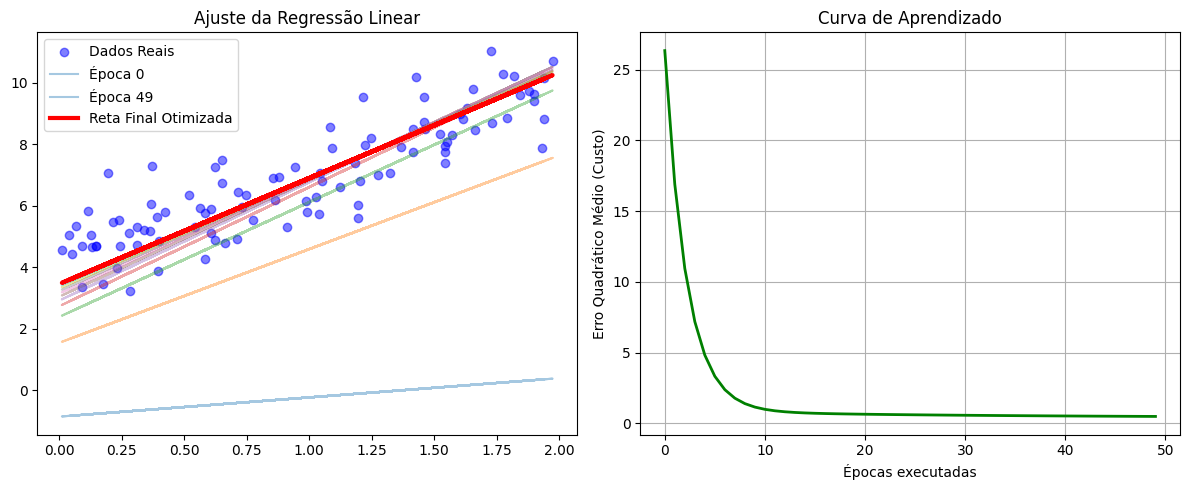

In [65]:
# ---------------------------------------------------------
# 3. Visualização da Reta "Aprendendo"
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot da evolução da reta
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.5, label="Dados Reais")

# Ajuste: A última época agora é dinâmica devido à parada antecipada
ultima_epoca_executada = len(historico_custo) - 1

for w_t, b_t, ep in historico_retas:
    # Exibe legenda apenas para a primeira e a última reta processada
    legenda = f"Época {ep}" if ep == 0 or ep == ultima_epoca_executada else ""
    plt.plot(X, w_t * X + b_t, alpha=0.4, label=legenda)

plt.plot(X, w * X + b, color='red', linewidth=3, label="Reta Final Otimizada")
plt.title("Ajuste da Regressão Linear")
plt.legend()

# Plot da Curva de Aprendizado (Custo caindo)
plt.subplot(1, 2, 2)
plt.plot(range(len(historico_custo)), historico_custo, 'g-', linewidth=2)
plt.title("Curva de Aprendizado")
plt.xlabel("Épocas executadas")
plt.ylabel("Erro Quadrático Médio (Custo)")
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. O Padrão Ouro: Otimizador ADAM (Adaptive Moment Estimation)

Até agora, usamos o Gradiente Descendente Convencional (SGD com lotes). Se errarmos na Taxa de Aprendizado ($\alpha$), o modelo pode nunca aprender.

O **Adam** é o algoritmo de otimização mais utilizado hoje em Deep Learning (TensorFlow/PyTorch). Ele resolve esse problema de duas formas:
1. **Momentum (Inércia):** Ele lembra para onde o gradiente estava indo. Se ele estiver descendo ladeira abaixo rápido, ele ganha "embalo" para passar por buracos (mínimos locais).
2. **Taxa Adaptativa (RMSprop):** Ele calcula um $\alpha$ individual para cada peso $w$. Se um peso varia muito, ele diminui o passo. Se varia pouco, ele aumenta o passo.

Vamos simular o Adam usando código nativo do Scikit-Learn (SGDRegressor puro vs. Adam via MLPRegressor) para ver a diferença de inteligência debaixo do capô.

In [66]:
from sklearn.linear_model import SGDRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import time

In [67]:
# 1. Configuração do SGD Tradicional
n_epochs = 200
tolerancia = 1e-4  # Limite para considerar que o modelo convergiu

modelo_sgd = SGDRegressor(learning_rate='constant', eta0=0.01, random_state=42)
loss_sgd = []

inicio_sgd = time.time()

for epoch in range(n_epochs):
    modelo_sgd.partial_fit(X, y.ravel())  # Treino incremental
    y_pred = modelo_sgd.predict(X)

    # Divisão por 2 para igualar à métrica interna do MLPRegressor (Half MSE)
    loss = mean_squared_error(y, y_pred) / 2
    loss_sgd.append(loss)

    # Verificação de convergência
    if epoch > 0:
        diferenca_loss = abs(loss_sgd[-2] - loss_sgd[-1])
        if diferenca_loss < tolerancia:
            break

tempo_sgd = time.time() - inicio_sgd

In [68]:
# 2. Configuração do Adam
inicio_adam = time.time()
modelo_adam = MLPRegressor(hidden_layer_sizes=(10,), solver='adam', learning_rate_init=0.01, max_iter=n_epochs, random_state=42)
modelo_adam.fit(X, y.ravel())
tempo_adam = time.time() - inicio_adam

In [69]:
# 3. Extraindo a evolução do erro (Curva de Perda)
loss_adam = modelo_adam.loss_curve_

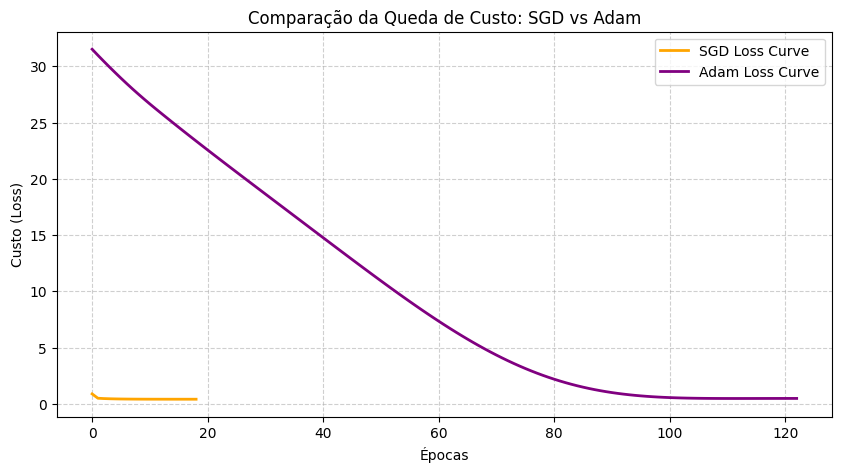

Tempo de execução SGD: 0.1836s
Tempo de execução ADAM: 0.4728s
Iterações executadas (SGD): 19
Iterações até convergência (ADAM): 123


In [70]:
# Plotando as Curvas de Aprendizado
plt.figure(figsize=(10, 5))
plt.plot(loss_sgd, label='SGD Loss Curve', color='orange', linewidth=2)
plt.plot(loss_adam, label='Adam Loss Curve', color='purple', linewidth=2)
plt.title('Comparação da Queda de Custo: SGD vs Adam')
plt.xlabel('Épocas')
plt.ylabel('Custo (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Tempo de execução SGD: {tempo_sgd:.4f}s")
print(f"Tempo de execução ADAM: {tempo_adam:.4f}s")
print(f"Iterações executadas (SGD): {len(loss_sgd)}")
print(f"Iterações até convergência (ADAM): {modelo_adam.n_iter_}")

## Por que o Adam perdeu na Regressão Linear Simples?

No cenário anterior, o SGD tradicional foi mais rápido e convergiu em menos iterações. Isso ocorre por dois motivos:
1. **Topologia Simples:** A regressão linear possui uma função de custo perfeitamente convexa (uma única "tigela"). O SGD vai direto ao fundo . O cálculo extra do Adam (inércia e variância) gera custo computacional desnecessário.
2. **Overhead de Arquitetura:** O `SGDRegressor` é otimizado para equações lineares. O `MLPRegressor` constrói a infraestrutura de uma rede neural, adicionando tempo de alocação de memória.

Para problemas lineares e rasos, algoritmos tradicionais são mais eficientes. O Adam foi criado para resolver problemas complexos e não-lineares.

# 7. O Cenário Complexo: Onde o Adam Brilha

Em problemas não-lineares, a função de custo deixa de ser uma tigela perfeita e passa a ter múltiplos vales, picos e platôs (mínimos locais e pontos de sela) .

Neste cenário, o SGD comum frequentemente fica preso em mínimos locais ou avança de forma extremamente lenta em áreas planas. O Adam supera essa limitação utilizando o **Momentum** (para "rolar" por cima de pequenos buracos) e a **Taxa Adaptativa** (para acelerar em áreas planas).

Abaixo, treinamos uma Rede Neural para aprender uma função não-linear (seno com ruído), comparando os otimizadores internamente.

In [19]:
# 1. Gerando dados complexos não-lineares (Curva Senoidal com ruído)
np.random.seed(42)
X_complexo = np.linspace(-5, 5, 300).reshape(-1, 1)
y_complexo = np.sin(X_complexo).ravel() + np.random.normal(0, 0.2, X_complexo.shape[0])

In [71]:
# 2. Configurando as Redes Neurais (mesma arquitetura, otimizadores diferentes)
# Arquitetura: 2 camadas ocultas com 50 neurônios cada
mlp_sgd = MLPRegressor(hidden_layer_sizes=(50, 50), solver='sgd', learning_rate_init=0.01, max_iter=400, random_state=42)
mlp_adam = MLPRegressor(hidden_layer_sizes=(50, 50), solver='adam', learning_rate_init=0.01, max_iter=400, random_state=42)

In [72]:
# 3. Treinamento e marcação de tempo (SGD)
inicio_sgd = time.time()
mlp_sgd.fit(X_complexo, y_complexo)
tempo_sgd = time.time() - inicio_sgd

In [73]:
# 4. Treinamento e marcação de tempo (Adam)
inicio_adam = time.time()
mlp_adam.fit(X_complexo, y_complexo)
tempo_adam = time.time() - inicio_adam

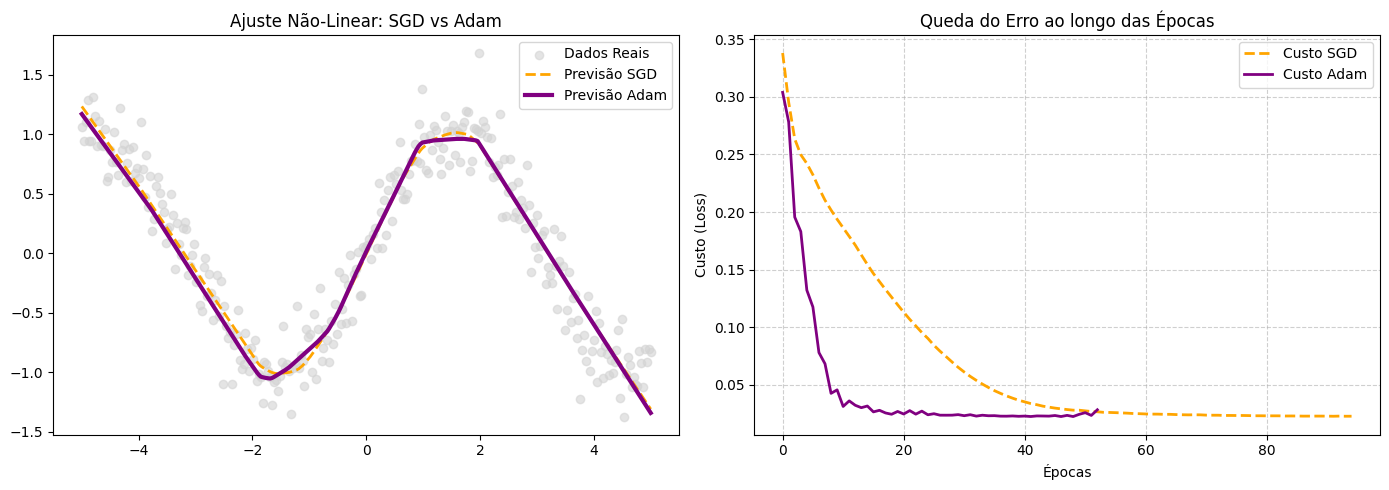

--- DESEMPENHO NO CENÁRIO COMPLEXO ---
SGD  -> Custo final: 0.0229 | Tempo: 0.20s | Épocas: 95
Adam -> Custo final: 0.0285 | Tempo: 0.13s | Épocas: 53


In [74]:
# 5. Resultados e Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Ajuste da Curva ---
ax1.scatter(X_complexo, y_complexo, color='lightgray', label='Dados Reais', alpha=0.6)
ax1.plot(X_complexo, mlp_sgd.predict(X_complexo), color='orange', linewidth=2, linestyle='--', label='Previsão SGD')
ax1.plot(X_complexo, mlp_adam.predict(X_complexo), color='purple', linewidth=3, label='Previsão Adam')
ax1.set_title('Ajuste Não-Linear: SGD vs Adam')
ax1.legend()

# --- Plot 2: Curva de Custo (Loss) ---
ax2.plot(mlp_sgd.loss_curve_, color='orange', linewidth=2, linestyle='--', label='Custo SGD')
ax2.plot(mlp_adam.loss_curve_, color='purple', linewidth=2, label='Custo Adam')
ax2.set_title('Queda do Erro ao longo das Épocas')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Custo (Loss)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Exibindo as métricas finais
print(f"--- DESEMPENHO NO CENÁRIO COMPLEXO ---")
print(f"SGD  -> Custo final: {mlp_sgd.loss_curve_[-1]:.4f} | Tempo: {tempo_sgd:.2f}s | Épocas: {mlp_sgd.n_iter_}")
print(f"Adam -> Custo final: {mlp_adam.loss_curve_[-1]:.4f} | Tempo: {tempo_adam:.2f}s | Épocas: {mlp_adam.n_iter_}")